# Hasil Konvergensi untuk Masalah Nilai Awal (Convergence Results for Initial Value Problems)


Konvergensi untuk Initial Value Problems (IVP) sedikit berbeda dibandingkan dengan Boundary Value Problems (BVP). Secara umum, yang kita inginkan adalah

$$
\lim_{\Delta t \rightarrow 0} U^N = u(t_f)
$$

di mana:

- $t_f$ adalah waktu akhir yang ingin dicapai,  
- $N$ adalah jumlah langkah waktu (time steps) yang diperlukan untuk mencapai $t_f$.

Jumlah langkah waktu tersebut memenuhi hubungan

$$
N \Delta t = t_f
\quad \Rightarrow \quad
N = \frac{t_f}{\Delta t}.
$$

Artinya, jika langkah waktu $\Delta t$ dibuat semakin kecil, maka solusi numerik $U^N$ akan semakin mendekati solusi sebenarnya $u(t_f)$ pada waktu akhir $t_f$.


Namun, pada tahap ini kita perlu berhati-hati ketika membicarakan metode yang konvergen. Suatu metode bisa saja konvergen untuk jenis persamaan tertentu dan kondisi awal tertentu, tetapi tidak konvergen untuk kasus yang lain.

Dalam praktiknya, kita menginginkan hasil konvergensi yang berlaku untuk cukup banyak jenis persamaan dan kondisi awal, bukan hanya untuk satu kasus tertentu saja.

Dengan mempertimbangkan hal tersebut, kita dapat merumuskan definisi konvergensi untuk Initial Value Problems (IVP) sebagai berikut.


Jika kita menerapkan metode r-langkah (r-step method) pada suatu ODE berbentuk

$$
u'(t) = f(t,u)
$$

dengan $f(t,u)$ bersifat Lipschitz kontinu terhadap $u$, dan dengan himpunan nilai awal yang memenuhi

$$
\lim_{\Delta t \rightarrow 0} U^\nu(\Delta t) = u_0 
\quad \text{untuk} \quad 
\nu = 0, 1, \ldots, r-1
$$

(artinya proses bootstrap awal pada metode multi-step konsisten dengan nilai awal ketika $\Delta t \rightarrow 0$),

maka metode tersebut dikatakan konvergen dalam arti

$$
\lim_{\Delta t \rightarrow 0} U^N = u(t_f).
$$


Seperti yang telah kita lihat sebelumnya, agar suatu metode konvergen, metode tersebut harus memenuhi dua syarat berikut:

- Konsisten (consistent) 
  Galat pemotongan lokal (local truncation error) memenuhi  
  $$
  \tau = \mathcal{O}(\Delta t^p)
  $$
  dengan $p > 0$.

- Zero-stable 
  Bentuk stabilitas minimum yang menyatakan bahwa akumulasi total galat ketika $\Delta t \rightarrow 0$ tetap terbatas, dan memiliki orde yang sama dengan $\tau$, yang kita ketahui juga akan menuju nol ketika $\Delta t \rightarrow 0$.


### Konvergensi Metode Satu Langkah

Perhatikan masalah linear sederhana berikut

$$
\frac{\text{d}u}{\text{d}t} = \lambda u + g(t) 
\quad \text{dengan} \quad 
u(0) = u_0
$$

yang kita ketahui memiliki solusi

$$
u(t) = u_0 e^{\lambda (t - t_0)} + \int^t_{t_0} e^{\lambda (t - \tau)} g(\tau) d\tau.
$$


### Metode Forward Euler pada Masalah Linear

Jika kita menerapkan metode Euler maju (Forward Euler) pada masalah ini, diperoleh

$$
\begin{aligned}
U^{n+1} &= U^n + \Delta t \lambda U^n \\
        &= (1 + \Delta t \lambda) U^n
\end{aligned}
$$


Kita juga mengetahui bahwa galat pemotongan lokal (local truncation error) adalah

$$
\begin{aligned}
\tau^n &= \left(\frac{u(t_{n+1}) - u(t_n)}{\Delta t}\right) - \lambda u(t_n) \\
&= \left(u'(t_n) + \frac{1}{2}\Delta t\, u''(t_n) + \mathcal{O}(\Delta t^2)\right) - u'(t_n) \\
&= \frac{1}{2}\Delta t\, u''(t_n) + \mathcal{O}(\Delta t^2)
\end{aligned}
$$


Dengan mengingat definisi awal dari $\tau^n$, kita dapat menuliskan kembali ekspresi galat pemotongan lokal sebagai

$$
u(t_{n+1}) = (1 + \Delta t \lambda) u(t_n) + \Delta t \tau^n
$$

Jika persamaan ini digabungkan dengan penerapan metode Euler, maka kita memperoleh ekspresi untuk galat global

$$
\begin{aligned}
E^{n+1} = U^{n+1} - u(t^{n+1}) 
&= (1 + \Delta t \lambda) U^n - (1 + \Delta t \lambda) u(t_n) - \Delta t \tau^n \\
&= (1 + \Delta t \lambda) E^n - \Delta t \tau^n
\end{aligned}
$$

Jika ekspresi ini diperluas kembali ke langkah waktu sebelumnya hingga $n=0$, maka diperoleh

$$
E^n = (1 + \Delta t \lambda) E^0 - \Delta t \sum^n_{i=1} (1 + \Delta t \lambda)^{n-i} \tau^{i-1}.
$$


Sekarang kita dapat melihat pentingnya suku $(1 + \Delta t \lambda)$.  
Suku ini dapat dibatasi dengan

$$
|1 + \Delta t \lambda| \leq e^{\Delta t \lambda}
$$

yang kemudian menunjukkan bahwa suku di dalam penjumlahan dapat dibatasi oleh

$$
|1 + \Delta t \lambda|^{n-i} 
\leq e^{(n-i)\Delta t |\lambda|}
\leq e^{n \Delta t |\lambda|}
\leq e^{|\lambda| t_f}
$$


Jika batas ini kita gunakan dalam persamaan galat global, maka diperoleh

$$
\begin{aligned}
E^n &= (1 + \Delta t \lambda) E^0 - \Delta t \sum^n_{i=1} (1 + \Delta t \lambda)^{n-i} \tau^{i - 1} \\
|E^n| &\leq e^{|\lambda| \Delta t} |E^0| - \Delta t \sum^n_{i=1} e^{|\lambda| t_f} |\tau^{i - 1}| \\
      &\leq e^{|\lambda| t_f} \left(|E^0| - \Delta t \sum^n_{i=1} |\tau^{i - 1}|\right) \\
      &\leq e^{|\lambda| t_f} \left(|E^0| - n \Delta t \max_{1 \leq i \leq n} |\tau^{i - 1}|\right)
\end{aligned}
$$


Dengan kata lain, galat global dibatasi oleh:
- galat awal (initial error), dan
- galat maksimum dari satu langkah perhitungan,

yang kemudian dikalikan dengan jumlah langkah waktu yang dilakukan.

Jika seperti sebelumnya kita gunakan

$$
N = \frac{t_f}{\Delta t}
$$

dan memperhitungkan local truncation error, maka ekspresi tersebut dapat disederhanakan menjadi

$$
|E^n| \leq e^{|\lambda| t_f}
\left[
|E^0| + t_f
\left(
\frac{1}{2}\Delta t |u''| + \mathcal{O}(\Delta t^2)
\right)
\right]
$$


Jika kita mengasumsikan bahwa kondisi awal yang digunakan benar, yaitu $u_0$, maka

$$
E_0 \rightarrow 0 \quad \text{ketika} \quad \Delta t \rightarrow 0
$$

Sehingga kita dapat melihat bahwa metode tersebut benar-benar konvergen, karena

$$
|E^n|
\leq
e^{|\lambda| t_f} \, t_f
\left(
\frac{1}{2}\Delta t |u''| + \mathcal{O}(\Delta t^2)
\right)
=
\mathcal{O}(\Delta t).
$$

Artinya, galat global berorde $\mathcal{O}(\Delta t)$, sehingga ketika $\Delta t$ semakin kecil, galat juga akan semakin kecil secara proporsional.


### Hubungan dengan Stabilitas pada BVP

Kita dapat melihat hubungan antara definisi stabilitas sebelumnya (pada BVP) dengan konsep stabilitas yang dijelaskan di atas. Salah satu caranya adalah dengan menuliskan metode Forward Euler dalam bentuk sistem linear.

#### Forward Euler

Matriks sistemnya dapat ditulis sebagai

$$
A = \frac{1}{\Delta t}
\begin{bmatrix}
1 \\
-(1 + \Delta t \lambda) & 1 \\
& -(1 + \Delta t \lambda) & 1 \\
& & -(1 + \Delta t \lambda) & 1 \\
& & & \ddots & \ddots \\
& & & & -(1 + \Delta t \lambda) & 1 \\
& & & & & -(1 + \Delta t \lambda) & 1
\end{bmatrix}
$$

dengan

$$
U =
\begin{bmatrix}
U^1 \\
U^2 \\
\vdots \\
U^N
\end{bmatrix}
\qquad
F =
\begin{bmatrix}
(1/\Delta t + \lambda) U^0 + g(t_0) \\
g(t_1) \\
\vdots \\
g(t_{N-1})
\end{bmatrix}
$$

Mengikuti hasil stabilitas sebelumnya, dan dengan mengambil $\hat{U}$ sebagai vektor yang diperoleh dari solusi sebenarnya (dengan $\hat{U}^i = u(t_i)$), maka kita memiliki

$$
A U = F
\qquad
A \hat{U} = F + \tau
$$

sehingga

$$
A(\hat{U} - U) = \tau.
$$

Karena $\hat{U} - U = E$ (galat global), maka

$$
A E = \tau.
$$

Selanjutnya kita dapat menginvers matriks $A$ untuk mendapatkan hubungan antara galat pemotongan (truncation error)  $\tau$ dan galat global $E$.

Seperti sebelumnya, kita membutuhkan bahwa:
- $A^{-1}$ ada (invertible)
- $||A^{-1}|| < C$ pada suatu norma tertentu.


Invers matriks $A$ dapat dituliskan sebagai

$$
A^{-1} =
\Delta t
\begin{bmatrix}
1 \\
(1 + \Delta t \lambda) & 1 \\
(1 + \Delta t \lambda)^2 & (1 + \Delta t \lambda) & 1 \\
(1 + \Delta t \lambda)^3 & (1 + \Delta t \lambda)^2 & (1 + \Delta t \lambda) & 1 \\
\vdots & & & \ddots \\
(1 + \Delta t \lambda)^{N-1} & (1 + \Delta t \lambda)^{N-2} & (1 + \Delta t \lambda)^{N-3} & \cdots & (1 + \Delta t \lambda) & 1
\end{bmatrix}
$$

Norma tak hingga dari matriks ini adalah

$$
||A^{-1}||_\infty
=
\Delta t
\sum_{m=1}^{N}
\left|
(1 + \Delta t \lambda)^{N-m}
\right|
$$

sehingga

$$
||A^{-1}||_\infty
\le
\Delta t N e^{|\lambda|T}
=
T e^{|\lambda|T}.
$$

Karena $T$ tetap (fixed), maka ketika

$$
\Delta t \rightarrow 0
$$

nilai ini tetap terbatas (bounded).

Ini menunjukkan bahwa metode Forward Euler stabil untuk waktu akhir yang tetap.


### Konvergensi Metode Satu Langkah Secara Umum

Perhatikan metode satu langkah umum yang dinyatakan sebagai

$$
U^{n+1} = U^n + \Delta t \, \Phi(U^n, t_n, \Delta t).
$$

Diasumsikan bahwa fungsi $\Phi$:

- kontinu terhadap $t$ dan $\Delta t$, dan  
- Lipschitz kontinu terhadap $u$ dengan konstanta Lipschitz $L$  
  (yang berkaitan dengan konstanta Lipschitz dari fungsi $f$).

Jika metode satu langkah tersebut konsisten, yaitu

$$
\Phi(u,t,0) = f(u,t)
$$

untuk semua $u$, $t$, dan $\Delta t$, serta galat pemotongan lokal (local truncation error) diberikan oleh

$$
\tau^n =
\frac{u(t_{n+1}) - u(t_n)}{\Delta t}
-
\Phi(u(t_n), t_n, \Delta t),
$$

maka metode satu langkah tersebut konvergen.


Dengan menggunakan pendekatan umum yang sama seperti pada metode Forward Euler, kita mengetahui bahwa solusi sebenarnya dan galat pemotongan $\tau$ berhubungan melalui

$$
u(t_{n+1}) =
u(t_n) +
\Delta t \, \Phi(u(t_n), t_n, \Delta t)
+
\Delta t \tau^n.
$$

Jika persamaan ini dikurangkan dari solusi aproksimasi

$$
U^{n+1} = U^n + \Delta t \, \Phi(U^n, t_n, \Delta t),
$$

maka diperoleh hubungan untuk galat global

$$
E^{n+1}
=
E^n
+
\Delta t
\left(
\Phi(U^n, t_n, \Delta t)
-
\Phi(u(t_n), t_n, \Delta t)
\right)
-
\Delta t \tau^n.
$$

Dengan menggunakan sifat Lipschitz kontinu dari $\Phi$, kita memperoleh

$$
|E^{n+1}|
\le
|E^n|
+
\Delta t L |E^n|
+
\Delta t |\tau^n|.
$$

Bentuk persamaan ini sama seperti yang kita temui pada pembuktian metode Forward Euler, sehingga langkah analisis konvergensinya juga mengikuti pola yang serupa.


### Zero-Stability untuk Metode Multistep Linear

Kita juga dapat membuat pernyataan umum untuk metode multistep linear, tetapi perlu diperhatikan bahwa metode ini memiliki persyaratan tambahan agar dapat bersifat konvergen.

Sebagai contoh, perhatikan metode berikut

$$
U^{n+2} - 3 U^{n+1} + 2 U^n = - \Delta t f(U^n)
$$

sehingga koefisiennya adalah

- $\alpha_0 = 2$
- $\alpha_1 = -3$
- $\alpha_2 = 1$

dan

- $\beta_0 = -1$

sementara koefisien lainnya sama dengan nol.

Koefisien-koefisien ini memenuhi syarat konsistensi, dengan galat pemotongan (truncation error)

$$
\tau^n =
\frac{1}{\Delta t}
\left(
u(t_{n+2}) - 3u(t_{n+1}) + 2u(t_n) + \Delta t\, u'(t_n)
\right)
=
\frac{5}{2} \Delta t\, u''(t_n)
+
\mathcal{O}(\Delta t^2).
$$

Namun ternyata, meskipun metode ini konsisten, galat globalnya tidak selalu konvergen


Perhatikan kembali metode

$$
U^{n+2} - 3 U^{n+1} + 2 U^n = - \Delta t f(U^n)
$$

Sekarang kita gunakan ODE yang sangat sederhana

$$
u'(t) = 0,
\qquad
u(0) = 0.
$$

Pada kasus ini metode tersebut menjadi

$$
U^{n+2} - 3 U^{n+1} + 2 U^n = 0.
$$


Jika kita memiliki nilai awal yang tepat untuk $U^0$ dan $U^1$, maka metode ini akan menghasilkan

$$
U^n = 0.
$$

Namun dalam praktiknya, biasanya kita hanya memiliki aproksimasi untuk $U^1$. Jadi apa yang terjadi jika terdapat sedikit kesalahan pada nilai awal tersebut?

Persamaan beda linear ini dapat diselesaikan dalam bentuk $U^0$ dan $U^1$, sehingga diperoleh

$$
U^n = 2U^0 - U^1 + 2^n (U^1 - U^0).
$$

Jika kita mengasumsikan bahwa terdapat galat pada orde $\mathcal{O}(\Delta t)$ pada $U^1$, maka nilai solusi dapat bertambah sangat besar dengan cepat, bahkan untuk nilai $n$ yang kecil.

Hal ini menunjukkan bahwa metode tersebut tidak stabil secara zero-stability, sehingga meskipun konsisten, metode ini tidak konvergen secara umum.

### Polinomial Karakteristik dan Persamaan Beda Linear

Sebagai penjelasan tambahan singkat, misalkan kita ingin menyelesaikan persamaan

$$
\sum^r_{j=0} \alpha_j U^{n+j} = 0
$$

dengan kondisi awal

$$
U^0, U^1, \ldots, U^{r-1}.
$$

Persamaan ini memiliki solusi umum berbentuk

$$
U^n = \xi^n.
$$


Jika kita substitusikan bentuk solusi tersebut ke dalam persamaan, maka diperoleh

$$
\sum^r_{j=0} \alpha_j \xi^{n+j} = 0.
$$

Kemudian dengan membagi kedua sisi dengan $\xi^n$, persamaan tersebut menjadi

$$
\sum^r_{j=0} \alpha_j \xi^j = 0.
$$


Jika $\xi$ merupakan akar dari polinomial

$$
\rho(\xi) = \sum^r_{j=0} \alpha_j \xi^j,
$$

maka nilai $\xi$ tersebut merupakan solusi dari persamaan beda di atas.


Perlu diperhatikan bahwa karena metode ini bersifat linear, maka kombinasi linear dari solusi-solusi juga merupakan solusi.

Oleh karena itu, bentuk umum dari solusi dapat dituliskan sebagai


$$
U^n =
c_1 \xi_1^n +
c_2 \xi_2^n +
\cdots +
c_r \xi_r^n.
$$

Jika diberikan nilai awal

$$
U^0, U^1, \ldots
$$

maka konstanta-konstanta $c_j$ dapat ditentukan secara unik.

### Hasil Umum Zero-Stability untuk Linear Multistep Methods (LMM)

Suatu metode Linear Multistep Method (LMM) dengan $r$ langkah dikatakan zero-stable jika akar-akar dari polinomial karakteristik $\rho(\xi)$ memenuhi

$$
|\xi_j| \leq 1 \quad \text{untuk} \quad j = 1,2,3,\ldots,r
$$

dengan syarat:

- jika akar $\xi_j$ **tidak berulang**, maka $|\xi_j| \le 1$
- jika akar **berulang**, maka harus memenuhi $|\xi_j| < 1$


### Contoh 1

Perhatikan metode multistep linear berikut

$$
U^{n+2} - 2U^{n+1} + U^n
=
\frac{\Delta t}{2}\left(f(U^{n+2}) - f(U^n)\right).
$$

Jika metode ini diterapkan pada ODE sederhana

$$
u'(t) = 0
$$

maka diperoleh persamaan beda

$$
U^{n+2} - 2U^{n+1} + U^n = 0.
$$

Polinomial karakteristiknya adalah

$$
\rho(\xi) = \xi^2 - 2\xi + 1 = (\xi - 1)^2.
$$

Solusi umumnya menjadi

$$
U^n = c_1 + c_2 n.
$$

Di sini terlihat bahwa walaupun kita memiliki nilai awal $U^0$ dan $U^1$, solusi masih bertambah secara linear terhadap $n$, sehingga akhirnya solusi akan menyimpang (divergen).


### Contoh 2

Perhatikan metode multistep linear berikut

$$
U^{n+3} - 2U^{n+2} + \frac{5}{4}U^{n+1} - \frac{1}{4}U^n
=
\frac{\Delta t}{4} f(U^n).
$$

Terapkan metode ini pada ODE

$$
u'(t) = 0.
$$

Maka diperoleh persamaan beda

$$
U^{n+3} - 2U^{n+2} + \frac{5}{4}U^{n+1} - \frac{1}{4}U^n = 0.
$$

Polinomial karakteristiknya adalah

$$
\rho(\xi)
=
\xi^3 - 2\xi^2 + \frac{5}{4}\xi - \frac{1}{4}
=0.
$$

Akar-akarnya adalah

$$
\xi_1 = 1, \qquad
\xi_2 = \xi_3 = \frac{1}{2}.
$$

Sehingga solusi umumnya

$$
U^n =
c_1 +
c_2 \frac{1}{2^n} +
c_3 n \frac{1}{2^n}.
$$

Solusi ini konvergen, karena faktor

$$
\frac{1}{2^n}
$$

akan menuju nol ketika $n$ semakin besar.


### Contoh: Metode Adams

Bentuk umum semua metode Adams adalah

$$
U^{n+r}
=
U^{n+r-1}
+
\Delta t
\sum_{j=0}^{r}
\beta_j f(U^{n+j}).
$$

Jika diterapkan pada ODE

$$
u'(t)=0,
$$

maka polinomial karakteristiknya adalah

$$
\rho(\xi)
=
\xi^r - \xi^{r-1}
=
(\xi - 1)\xi^{r-1}.
$$

Akar-akarnya adalah

$$
\xi_1 = 1,
\qquad
\xi_2 = \xi_3 = \cdots = \xi_r = 0.
$$

Akar-akar ini memenuhi syarat zero-stability, sehingga dapat disimpulkan bahwa semua metode Adams bersifat konvergen.

### Stabilitas Absolut (Absolute Stability)

Walaupun zero-stability menjamin kestabilan metode, dalam praktiknya konsep ini sering sulit digunakan karena melibatkan limit  
$\Delta t \rightarrow 0$, yang tidak selalu mudah dihitung.

Sebagai alternatif, kita biasanya mempertimbangkan nilai $\Delta t$ yang terbatas dan memeriksa apakah metode tetap stabil untuk nilai tersebut.  
Keuntungan pendekatan ini adalah kita dapat mengetahui nilai $\Delta t$ tertentu yang menjamin metode tetap stabil.


### Contoh

Pertimbangkan masalah nilai awal berikut

$$
u'(t) = \lambda (u - \cos t) - \sin t, \qquad u(0) = 1
$$

yang memiliki solusi eksak

$$
u(t) = \cos t.
$$

Kita dapat memperkirakan nilai $\Delta t$ yang diperlukan dengan melihat truncation error

$$
\begin{aligned}
\tau &= \frac{1}{2}\Delta t\,u''(t) + \mathcal{O}(\Delta t^2) \\
     &= -\frac{1}{2}\Delta t \cos t + \mathcal{O}(\Delta t^2)
\end{aligned}
$$

Sehingga diperoleh batas galat

$$
|E^n| \leq \Delta t \max_{0 \leq t \leq t_f} |\cos t| = \Delta t.
$$

Jika kita menginginkan solusi dengan

$$
|E^n| < 10^{-3},
$$

maka kita membutuhkan

$$
\Delta t \approx 10^{-3}.
$$

Selanjutnya kita akan menerapkan metode Euler pada kasus

- $\lambda = -10$
- $\lambda = -2100$

untuk melihat bagaimana stabilitas metode bergantung pada nilai $\Delta t$ dan $\lambda$.

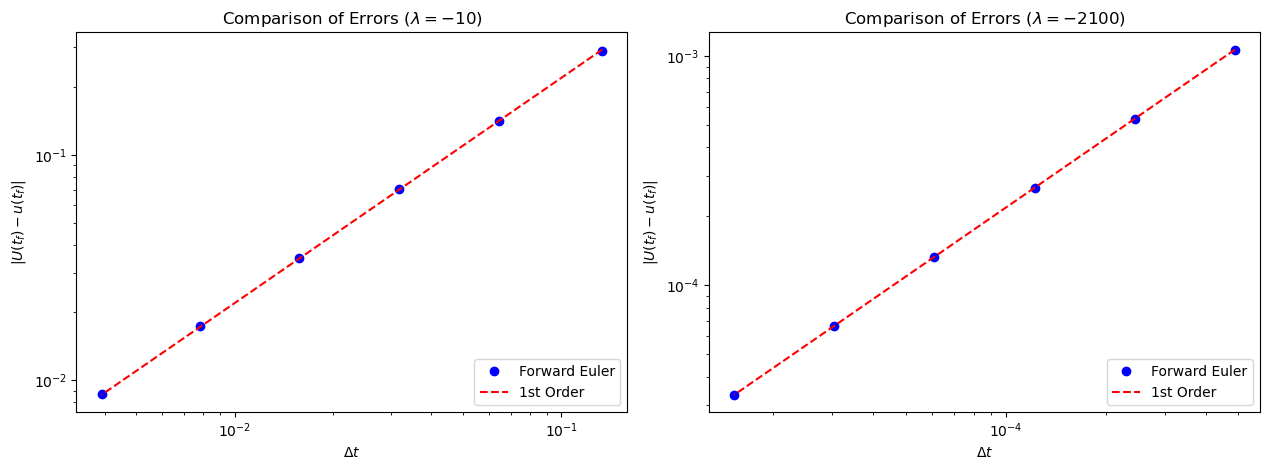

In [5]:
import numpy
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # sembunyikan warning overflow

# Definisi fungsi ODE dan solusi eksak
f = lambda t, lam, u: lam * (u - numpy.cos(t)) - numpy.sin(t)  # fungsi ODE
u_exact = lambda t: numpy.cos(t)  # solusi eksak

t_f = 2.0

# Dua range berbeda: kecil untuk lambda=-10, sangat kecil untuk lambda=-2100
num_steps_10   = [2**n for n in range(4, 10)]   # untuk lambda = -10
num_steps_2100 = [2**n for n in range(12, 18)]  # untuk lambda = -2100 (delta_t lebih kecil)

order_C = lambda delta_x, error, order: numpy.exp(numpy.log(error) - order * numpy.log(delta_x))

# Hitung error lambda = -10
delta_t_10 = numpy.empty(len(num_steps_10))
error_10   = numpy.empty(len(num_steps_10))
for (i, N) in enumerate(num_steps_10):
    t = numpy.linspace(0, t_f, N)
    delta_t_10[i] = t[1] - t[0]
    U = numpy.empty(t.shape)
    U[0] = 1.0
    for (n, t_n) in enumerate(t[1:]):
        U[n+1] = U[n] + delta_t_10[i] * f(t_n, -10.0, U[n])  # skema Euler maju
    error_10[i] = numpy.abs(U[-1] - u_exact(t_f)) / numpy.abs(u_exact(t_f))  # galat relatif

# Hitung error lambda = -2100
delta_t_2100 = numpy.empty(len(num_steps_2100))
error_2100   = numpy.empty(len(num_steps_2100))
for (i, N) in enumerate(num_steps_2100):
    t = numpy.linspace(0, t_f, N)
    delta_t_2100[i] = t[1] - t[0]
    U = numpy.empty(t.shape)
    U[0] = 1.0
    for (n, t_n) in enumerate(t[1:]):
        U[n+1] = U[n] + delta_t_2100[i] * f(t_n, -2100.0, U[n])
    error_2100[i] = numpy.abs(U[-1] - u_exact(t_f)) / numpy.abs(u_exact(t_f))

# Plot
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)

# Subplot kiri: lambda = -10
axes = fig.add_subplot(1, 2, 1)
axes.loglog(delta_t_10, error_10, 'bo', label='Forward Euler')
axes.loglog(delta_t_10, order_C(delta_t_10[1], error_10[1], 1.0) * delta_t_10**1.0, 'r--', label="1st Order")
axes.legend(loc=4)
axes.set_title(r"Comparison of Errors ($\lambda=-10$)")
axes.set_xlabel(r"$\Delta t$")
axes.set_ylabel(r"$|U(t_f) - u(t_f)|$")

# Subplot kanan: lambda = -2100
axes = fig.add_subplot(1, 2, 2)
valid = numpy.isfinite(error_2100)
axes.loglog(delta_t_2100[valid], error_2100[valid], 'bo', label='Forward Euler')
axes.loglog(delta_t_2100[valid], order_C(delta_t_2100[valid][1], error_2100[valid][1], 1.0) * delta_t_2100[valid]**1.0, 'r--', label="1st Order")
axes.legend(loc=4)
axes.set_title(r"Comparison of Errors ($\lambda=-2100$)")
axes.set_xlabel(r"$\Delta t$")
axes.set_ylabel(r"$|U(t_f) - u(t_f)|$")

plt.tight_layout()
plt.show()


**Apa yang Salah dengan $\lambda = -2100$?** 

Galat global seharusnya berkembang sebagai:
$$E^{n+1} = (1 + \Delta t \lambda) E^n - \Delta t T^n$$

Jika $\Delta t \approx 10^{-3}$, maka untuk kasus $\lambda = -10$, galat global sebelumnya dikalikan dengan:
$$1 + 10^{-3} \cdot -10 = 0.99$$
yang berarti kontribusi dari $E^n$ akan **perlahan berkurang** seiring bertambahnya langkah waktu. Untuk kasus lainnya kita mendapatkan:
$$1 + 10^{-3} \cdot -2100 = -1.1$$
yang berarti untuk $\Delta t$ ini, galat yang dibuat pada langkah waktu sebelumnya akan **terus membesar!** Agar hal ini tidak terjadi, kita harus memiliki $\Delta t < 1/2100$ yang akan membawa kembali ke konvergensi.

**Kestabilan Absolut Metode Euler Maju**

Perhatikan kembali persamaan uji sederhana $u'(t) = \lambda u$. Kita tahu dari sebelumnya bahwa penerapan metode Euler pada persoalan ini menghasilkan pembaruan berbentuk:
$$U_{n+1} = (1 + \Delta t \lambda) U_n$$

Seperti yang mungkin sudah jelas dari contoh sebelumnya, kita tahu bahwa jika:
$$|1 + \Delta t \lambda| \leq 1$$
maka metode tersebut akan **stabil**, dan ini disebut **kestabilan absolut**. Perlu dicatat bahwa hasil kali $\Delta t \lambda$ adalah yang terpenting di sini. Kita sering mempertimbangkan suatu **wilayah kestabilan absolut** pada bidang kompleks yang didefinisikan oleh persamaan di atas, di mana sekarang $z = \Delta t \lambda$. Hal ini memungkinkan nilai $\lambda$ bersifat kompleks, yang bisa menjadi kasus penting untuk dipertimbangkan, terutama untuk sistem persamaan di mana $\lambda$ diidentifikasi sebagai **nilai eigen**.

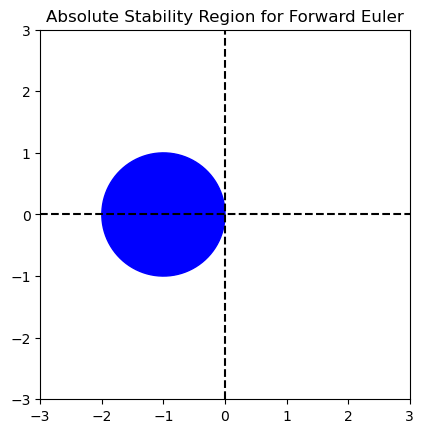

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Plot the region of absolute stability for Forward Euler
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

t = np.linspace(0.0, 2.0 * np.pi, 100) # Membuat parameter sudut dari 0 sampai 2π (untuk lingkaran)

axes.fill(np.cos(t) - 1.0, np.sin(t), color='blue') # Menggambar dan mengisi lingkaran: x = cos(t) - 1 → geser lingkaran ke kiri sejauh 1 y = sin(t) → lingkaran radius 1
axes.plot([-3, 3], [0.0, 0.0], 'k--') # garis horizontal (sumbu real) dari -3 sampai 3
axes.plot([0.0, 0.0], [-3, 3], 'k--') # garis vertikal (sumbu imajiner) dari -3 sampai 3

axes.set_xlim((-3, 3.0)) # Mengatur batas sumbu x dari -3 sampai 3
axes.set_ylim((-3, 3))   # Mengatur batas sumbu y dari -3 sampai 3
axes.set_aspect('equal') # Menyamakan skala sumbu x dan y agar lingkaran tidak lonjong

axes.set_title("Absolute Stability Region for Forward Euler")

plt.show()

**Wilayah Stabilitas Umum untuk Metode Multistep Linear**

Kembali ke metode multistep linear dan menerapkannya secara umum pada persoalan uji kita:
$$
    \sum^r_{j=0} \alpha_j U_{n+j} = \Delta t \sum^r_{j=0} \beta_j \lambda U_{n+j}
$$
yang dapat ditulis sebagai:
$$
    \sum^r_{j=0} (\alpha_j - \beta_j \Delta t \lambda) U_{n+j} = 0
$$
atau menggunakan notasi $z = \Delta t \lambda$:
$$
    \sum^r_{j=0} (\alpha_j - \beta_j z) U_{n+j} = 0.
$$

Bentuk ini memiliki kesamaan dengan persamaan beda linear yang telah dibahas sebelumnya! Dengan mendefinisikan:
$$
    \rho(\xi) = \sum^r_{j=0} \alpha_j \xi^j
$$
dan
$$
    \sigma(\xi) = \sum^r_{j=0} \beta_j \xi^j
$$
kita dapat menulis ekspresi di atas sebagai:
$$
    \pi(\xi, z) = \rho(\xi) - z \sigma(\xi)
$$
yang disebut **polinomial stabilitas** dari metode multistep linear.

Ternyata jika akar-akar $\xi_i$ dari polinomial ini memenuhi:
$$
    |\xi_i| \leq 1
$$
maka metode multistep tersebut bersifat stabil-absolut. Kemudian kita mendefinisikan wilayah kestabilan absolut sebagai nilai-nilai $z$ yang memenuhi kondisi ini. Pendekatan ini juga dapat diterapkan pada metode satu-langkah.

**Contoh: Metode Euler Maju**

Mengamati metode Euler maju, kita memiliki:
$$\begin{aligned}
    0 &= U_{n+1} - U_n - \Delta t \lambda U_n \\
    &= U_{n+1} - U_n (1 + \Delta t \lambda)\\
    &= \xi - 1 (1 + z)\\
    &=\pi(\xi, z)
\end{aligned}$$
yang akarnya adalah $\xi = 1 + z$, sehingga kita telah menurunkan kembali wilayah stabilitas yang telah ditemukan sebelumnya.

**Kestabilan Absolut Metode Euler Mundur**

Versi mundur dari metode Euler didefinisikan sebagai:
$$
    U_{n+1} = U_n + \Delta t f(t_{n+1}, U_{n+1}).
$$

Periksa apakah Euler mundur bersifat stabil-absolut.

Jika kita kembali mempertimbangkan persoalan uji sebelumnya, kita menemukan bahwa:
$$\begin{aligned}
    0 &= U_{n+1} (1 - \Delta t \lambda) - U_n \\
    &= \xi (1 - z) - 1
\end{aligned}$$
yang memiliki akar $\xi = \frac{1}{1 - z}$. Kemudian kita peroleh:
$$
    \left|\frac{1}{1-z}\right| \leq 1 \leftrightarrow |1 - z| \geq 1
$$
sehingga wilayah stabilitas mencakup seluruh bidang kompleks kecuali lingkaran yang berpusat di $(1, 0)$ dengan jari-jari 1, yang mengimplikasikan bahwa metode Euler mundur sebenarnya stabil untuk sembarang pilihan $\Delta t$.

**Penerapan pada ODE Kaku (*Stiff*)**

Perhatikan kembali ODE yang telah kita pelajari sebelumnya:
$$u'(t) = \lambda (u - \cos t) - \sin t$$
namun kali ini dengan kondisi awal umum $u(t_0) = \eta$. Apa yang terjadi pada solusi yang sedikit berbeda dari $\eta = 1$ atau $t_0 = 0$? Solusi umum dari ODE ini adalah:
$$u(t) = e^{\lambda (t - t_0)} (\eta - \cos t_0) + \cos t.$$

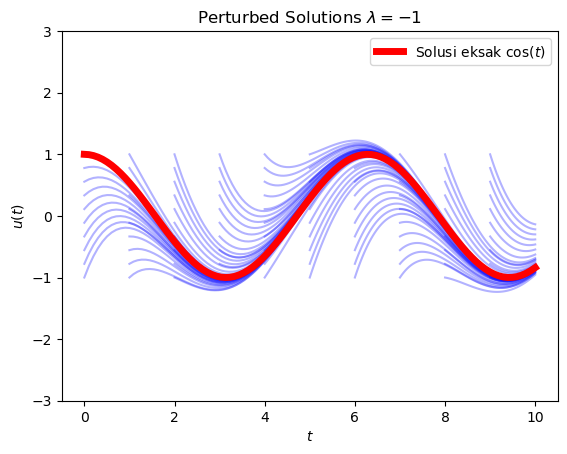

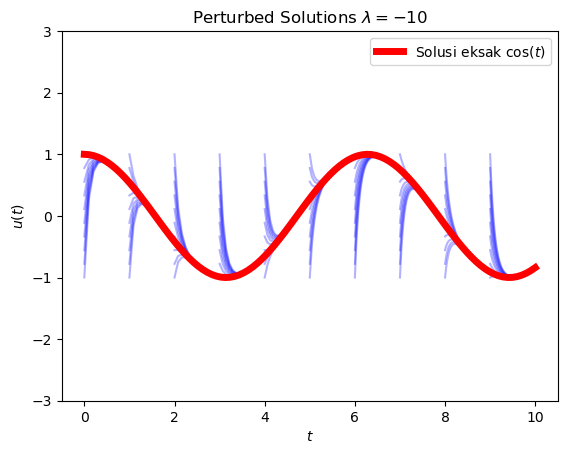

In [6]:
import numpy
import matplotlib.pyplot as plt

# Solusi umum ODE dengan kondisi awal sembarang
u = lambda t_0, eta, lam, t: numpy.exp(lam * (t - t_0)) * (eta - numpy.cos(t_0)) + numpy.cos(t)

for lam in [-1, -10]:
    fig = plt.figure()
    axes = fig.add_subplot(1, 1, 1)
    
    # Plot solusi terganggu (biru) untuk berbagai eta dan t_0
    for eta in numpy.linspace(-1, 1, 10):
        for t_0 in numpy.linspace(0.0, 9.0, 10):
            t = numpy.linspace(t_0, 10.0, 100)
            axes.plot(t, u(t_0, eta, lam, t), 'b', alpha=0.3)  # alpha agar tidak terlalu pekat
    
    # Plot solusi eksak (merah tebal)
    t = numpy.linspace(0.0, 10.0, 100)
    axes.plot(t, numpy.cos(t), 'r', linewidth=5, label='Solusi eksak $\cos(t)$')
    
    axes.set_title(r"Perturbed Solutions $\lambda = %s$" % lam)
    axes.set_xlabel(r'$t$')
    axes.set_ylabel(r'$u(t)$')
    axes.set_ylim(-3, 3)  # batasi sumbu y agar plot rapi
    axes.legend()

plt.show()

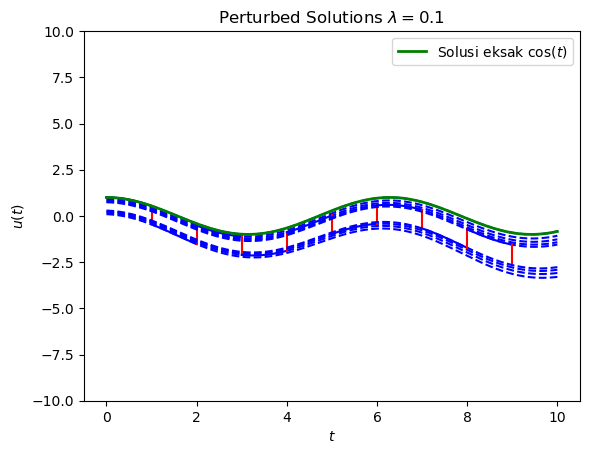

In [7]:
import numpy
import matplotlib.pyplot as plt

# Solusi umum ODE dengan kondisi awal sembarang
u = lambda t_0, eta, lam, t: numpy.exp(lam * (t - t_0)) * (eta - numpy.cos(t_0)) + numpy.cos(t)

num_steps = 10
error = numpy.ones(num_steps) * 1.0
t_hat = numpy.linspace(0.0, 10.0, num_steps + 1)
t_whole = numpy.linspace(0.0, 10.0, 1000)

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

eta = 1.0
lam = 0.1  # lambda positif -> solusi menjauhi cos(t)

for n in range(1, num_steps):
    t = numpy.linspace(t_hat[n-1], t_hat[n], 100)
    U = u(t_hat[n-1], eta, lam, t)
    
    axes.plot(t, U, 'b')                                                # solusi lokal (biru)
    axes.plot(t_whole, u(t_hat[n-1], eta, lam, t_whole), 'b--')        # perpanjangan solusi (biru putus)
    axes.plot([t[-1], t[-1]], [U[-1], U[-1] + (-1.0)**n * error[n]], 'r')  # gangguan tiap langkah (merah)
    
    eta = U[-1] + (-1.0)**n * error[n]  # perbarui kondisi awal dengan gangguan

# Plot solusi eksak
t = numpy.linspace(0.0, 10.0, 100)
axes.plot(t, numpy.cos(t), 'g', linewidth=2, label=r'Solusi eksak $\cos(t)$')  # solusi eksak (hijau)

axes.set_title(r"Perturbed Solutions $\lambda = %s$" % lam)
axes.set_xlabel(r'$t$')
axes.set_ylabel(r'$u(t)$')
axes.set_ylim((-10, 10))
axes.legend()
plt.show()

**Contoh: Sistem Kimia**

Perhatikan transisi zat kimia $A$ menjadi zat kimia $C$ melalui proses:
$$A \overset{K_1}{\rightarrow} B \overset{K_2}{\rightarrow} C.$$

Jika kita definisikan:
$$\vec{u} = \begin{bmatrix} [A] \\ [B] \\ [C] \end{bmatrix}$$

maka reaksi kimia sederhana ini dapat dimodelkan dengan sistem ODE:
$$\frac{\text{d} \vec{u}}{\text{d} t} = 
\begin{bmatrix}
    -K_1 & 0 & 0 \\
    K_1 & -K_2 & 0 \\
    0 & K_2 & 0
\end{bmatrix} \vec{u}$$

Solusi dari sistem ini berbentuk:
$$u_j(t) = c_{j1} e^{-K_1 t} + c_{j2}e^{-K_2 t} + c_{j3}$$

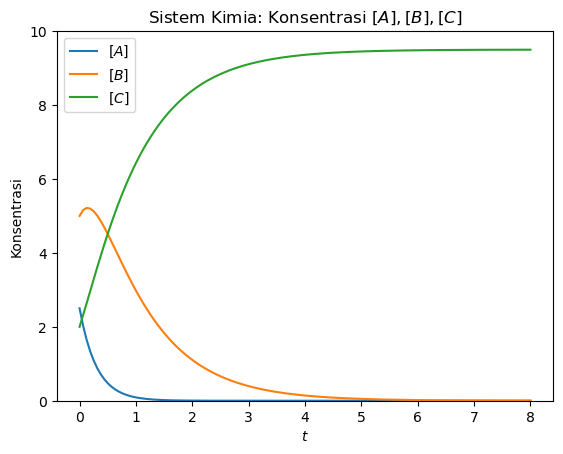

In [8]:
import numpy
import matplotlib.pyplot as plt

# Parameter masalah
K_1 = 3
K_2 = 1
# K_1 = 30.0  # kasus kaku (stiff)
# K_2 = 1.0

# Matriks sistem ODE
A = numpy.array([[-K_1, 0, 0],
                 [K_1, -K_2, 0],
                 [0,    K_2, 0]])

f = lambda u: numpy.dot(A, u)  # fungsi ruas kanan ODE

# Diskretisasi waktu
t = numpy.linspace(0.0, 8.0, 128)
delta_t = t[1] - t[0]  # ukuran langkah waktu

# Solusi dengan Euler maju
U = numpy.empty((t.shape[0], 3))
U[0, :] = [2.5, 5.0, 2.0]  # kondisi awal [A], [B], [C]

for n in range(t.shape[0] - 1):
    U[n+1, :] = U[n, :] + delta_t * f(U[n, :])  # skema Euler maju

# Plot hasil
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, U[:, 0], label='$[A]$')  # konsentrasi A
axes.plot(t, U[:, 1], label='$[B]$')  # konsentrasi B
axes.plot(t, U[:, 2], label='$[C]$')  # konsentrasi C
axes.set_title("Sistem Kimia: Konsentrasi $[A], [B], [C]$")
axes.set_xlabel(r"$t$")
axes.set_ylabel("Konsentrasi")
axes.set_ylim((0.0, 10.0))
axes.legend()
plt.show()

**Apa itu Kekakuan (*Stiffness*)?**

Secara umum, suatu ODE disebut **kaku** (*stiff*) jika $u'(t) \ll f'(t, u)$. Untuk sistem ODE, **rasio kekakuan**:
$$\frac{\max_p |\lambda_p|}{\min_p |\lambda_p|}$$
dapat digunakan untuk mengkarakterisasi kekakuan sistem tersebut. Pada contoh sebelumnya, rasio ini adalah $K_1 / K_2$ jika $K_1 > K_2$.

Ketika rasio ini diperbesar, kita mengamati bahwa metode numerik menjadi tidak stabil — hanya pengurangan $\Delta t$ yang dapat menghasilkan solusi yang stabil kembali. Bagi metode langkah waktu eksplisit, hal ini menjadi masalah karena pengurangan langkah waktu hanya untuk satu spesies saja menyebabkan komputasi menjadi sangat mahal.

Sebagai contoh, Euler maju memiliki kriteria stabilitas:
$$|1 + \Delta t \lambda| < 1$$
di mana $\lambda$ harus merupakan nilai eigen maksimum dari sistem.

z = Δt · λ = -3.0
z = Δt · λ = -1.0


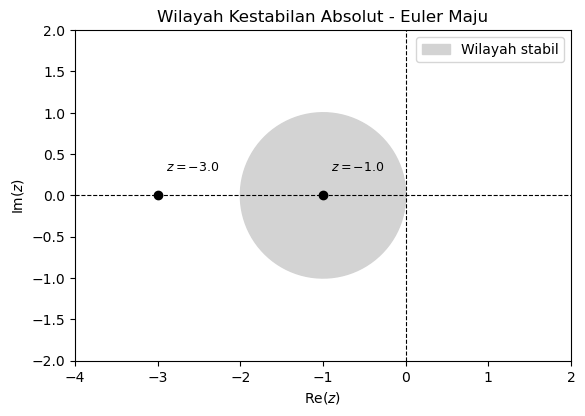

In [9]:
import numpy
import matplotlib.pyplot as plt

# Plot wilayah kestabilan absolut untuk Euler Maju
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

t = numpy.linspace(0.0, 2.0 * numpy.pi, 100)

# Parameter sistem kimia
K_1 = 3.0
K_2 = 1.0
delta_t = 1.0
eigenvalues = [-K_1, -K_2]  # nilai eigen sistem

# Plot wilayah stabil: lingkaran berpusat di (-1, 0) jari-jari 1
axes.fill(numpy.cos(t) - 1.0, numpy.sin(t), color='lightgray', label='Wilayah stabil')

# Plot posisi z = delta_t * lambda untuk tiap nilai eigen
for lam in eigenvalues:
    z = lam * delta_t  # nilai z pada sumbu real
    print(f"z = Δt · λ = {z}")
    axes.plot(z, 0.0, 'ko')
    axes.annotate(f'$z={z:.1f}$', xy=(z, 0.0),
                  xytext=(z + 0.1, 0.3), fontsize=9)  # label tiap titik

# Sumbu koordinat
axes.plot([-4, 2], [0.0, 0.0], 'k--', linewidth=0.8)  # sumbu real
axes.plot([0.0, 0.0], [-2, 2], 'k--', linewidth=0.8)  # sumbu imajiner

axes.set_xlim((-4, 2))
axes.set_ylim((-2, 2))
axes.set_aspect('equal')
axes.set_xlabel(r"Re$(z)$")
axes.set_ylabel(r"Im$(z)$")
axes.set_title("Wilayah Kestabilan Absolut - Euler Maju")
axes.legend(loc='upper right')
plt.show()

**A-Stabilitas**

Bagaimana jika kita dapat memperluas wilayah kestabilan absolut untuk mencakup lebih banyak bagian dari setengah bidang kiri, atau bahkan seluruhnya? Metode yang memiliki sifat ini disebut **A-stabil**.

Kita telah melihat satu contohnya pada Euler mundur, yang memiliki wilayah stabilitas:
$$|1 - z| \geq 1$$
yang mencakup seluruh setengah bidang kiri.

Ternyata, untuk metode multistep linear, sebuah teorema oleh **Dahlquist** membuktikan bahwa tidak ada LMM yang memenuhi kriteria A-stabilitas di atas orde kedua (aturan trapesium). Namun demikian, terdapat metode Runge-Kutta orde lebih tinggi yang memenuhinya.

Mungkin saja hal ini terlalu membatasi. Seringkali nilai eigen besar pada suatu sistem — misalnya yang berasal dari diskretisasi PDE untuk persamaan panas — terletak sepenuhnya pada garis real. Jika wilayah stabilitas dapat mencakup sebanyak mungkin bagian dari garis real sambil mengabaikan bagian lain dari setengah bidang kiri, kita mungkin bisa mendapatkan metode yang lebih efisien. Terdapat sejumlah metode yang dapat dikonstruksi dengan sifat ini namun berorde lebih tinggi.

z = Δt · λ = -3.0
z = Δt · λ = -1.0


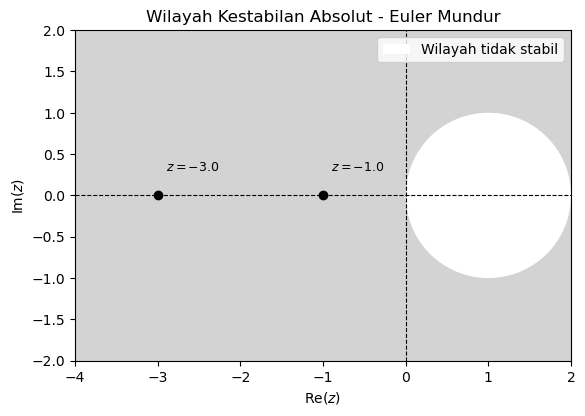

In [10]:
import numpy
import matplotlib.pyplot as plt

# Plot wilayah kestabilan absolut untuk Euler Mundur
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

t = numpy.linspace(0.0, 2.0 * numpy.pi, 100)

# Parameter sistem kimia
K_1 = 3.0
K_2 = 1.0
delta_t = 1.0
eigenvalues = [-K_1, -K_2]  # nilai eigen sistem

# Wilayah stabil = seluruh bidang kecuali lingkaran berpusat di (1, 0)
axes.set_facecolor('lightgray')                                          # seluruh bidang = stabil
axes.fill(numpy.cos(t) + 1.0, numpy.sin(t), 'w', label='Wilayah tidak stabil')  # lubang putih di (1,0)

# Plot posisi z = delta_t * lambda untuk tiap nilai eigen
for lam in eigenvalues:
    z = lam * delta_t  # nilai z pada sumbu real
    print(f"z = Δt · λ = {z}")
    axes.plot(z, 0.0, 'ko')
    axes.annotate(f'$z={z:.1f}$', xy=(z, 0.0),
                  xytext=(z + 0.1, 0.3), fontsize=9)  # label tiap titik

# Sumbu koordinat
axes.plot([-4, 2], [0.0, 0.0], 'k--', linewidth=0.8)  # sumbu real
axes.plot([0.0, 0.0], [-2, 2], 'k--', linewidth=0.8)  # sumbu imajiner

axes.set_xlim((-4, 2))
axes.set_ylim((-2, 2))
axes.set_aspect('equal')
axes.set_xlabel(r"Re$(z)$")
axes.set_ylabel(r"Im$(z)$")
axes.set_title("Wilayah Kestabilan Absolut - Euler Mundur")
axes.legend(loc='upper right')
plt.show()

**L-Stabilitas**

Ternyata tidak semua metode A-stabil itu sama. Perhatikan metode Euler mundur dan metode trapesium. Polinomial stabilitas untuk metode trapesium adalah:

$$\begin{aligned}
    0 &= U_{n+1} - U_n - \Delta t \frac{1}{2} (\lambda U_n + \lambda U_{n+1}) \\
      &= U_{n+1}\left(1 - \frac{1}{2} \Delta t \lambda \right ) - U_n \left(1 + \frac{1}{2}\Delta t \lambda \right) \\
      &= \left(\xi - \frac{1 + \frac{1}{2}z}{1 - \frac{1}{2} z}\right) \left(1 - \frac{1}{2} z \right )\\
\end{aligned}$$

yang menunjukkan bahwa metode ini bersifat A-stabil. Mari kita terapkan kedua metode ini pada persoalan yang telah kita lihat sebelumnya dan amati hasilnya.

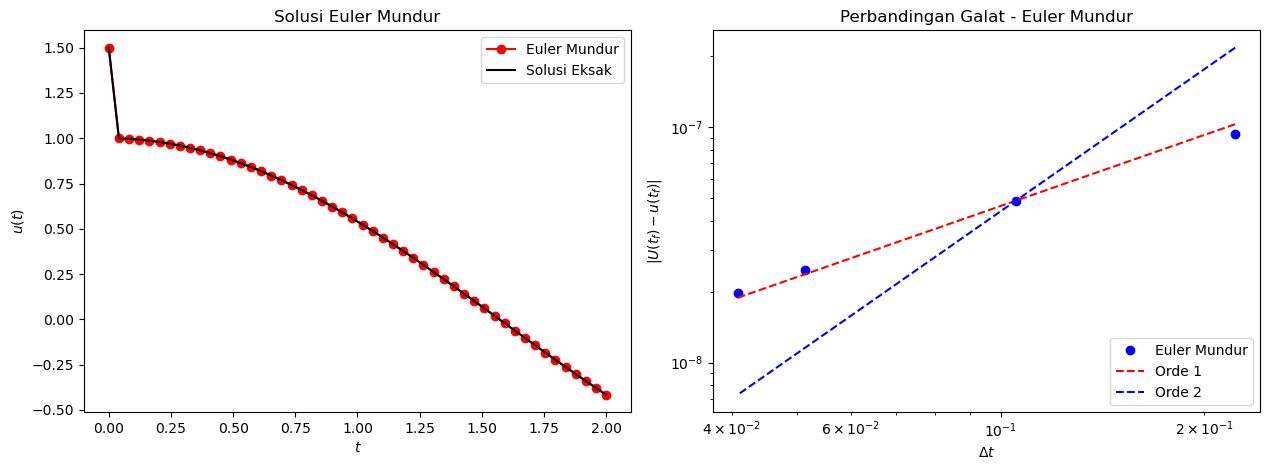

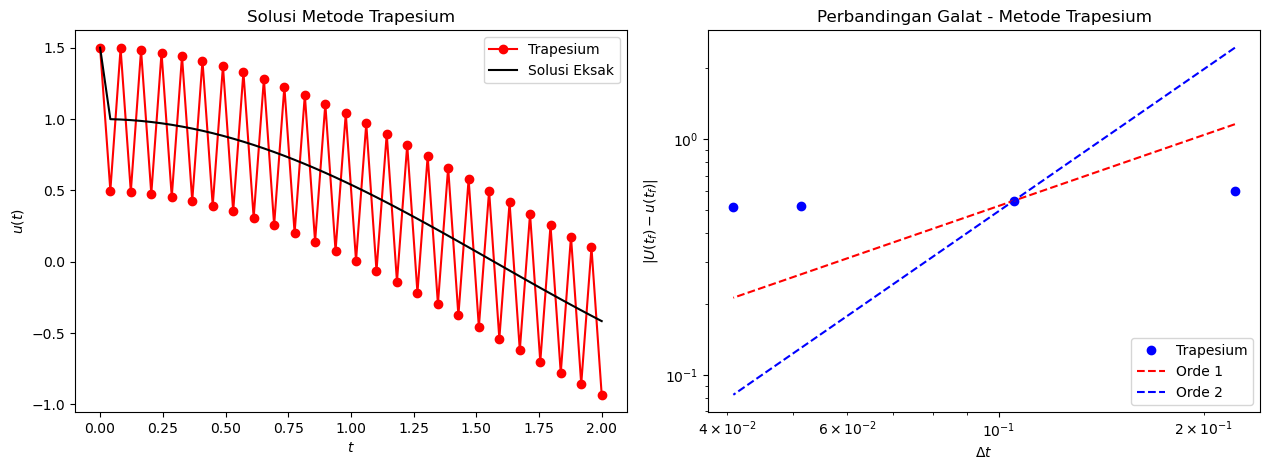

In [11]:
import numpy
import matplotlib.pyplot as plt

# Definisi fungsi ODE dan solusi eksak
f = lambda t, lam, u: lam * (u - numpy.cos(t)) - numpy.sin(t)  # fungsi ODE
u_exact = lambda t_0, eta, lam, t: numpy.exp(lam * (t - t_0)) * (eta - numpy.cos(t_0)) + numpy.cos(t)  # solusi eksak

t_0  = 0.0
eta  = 1.5
lam  = -1e6       # lambda sangat besar -> persoalan kaku
t_f  = 2.0
num_steps = [10, 20, 40, 50]

delta_t     = numpy.empty(len(num_steps))
error_euler = numpy.empty(len(num_steps))
error_trap  = numpy.empty(len(num_steps))

for (i, N) in enumerate(num_steps):
    t        = numpy.linspace(0, t_f, N)
    delta_t[i] = t[1] - t[0]  # ukuran langkah waktu
    u        = u_exact(t_0, eta, lam, t_f)  # nilai eksak di t_f

    # Euler mundur (implisit)
    U_euler    = numpy.empty(t.shape)
    U_euler[0] = eta  # kondisi awal
    for (n, t_n) in enumerate(t[1:]):
        U_euler[n+1] = (U_euler[n] - lam * delta_t[i] * numpy.cos(t_n) - delta_t[i] * numpy.sin(t_n)) / (1.0 - lam * delta_t[i])
    error_euler[i] = numpy.abs(U_euler[-1] - u) / numpy.abs(u)  # galat relatif

    # Metode trapesium (implisit)
    U_trap    = numpy.empty(t.shape)
    U_trap[0] = eta  # kondisi awal
    for (n, t_n) in enumerate(t[1:]):
        U_trap[n+1] = (U_trap[n] + delta_t[i] * 0.5 * f(t_n, lam, U_trap[n])
                       - 0.5 * lam * delta_t[i] * numpy.cos(t_n)
                       - 0.5 * delta_t[i] * numpy.sin(t_n)) / (1.0 - 0.5 * lam * delta_t[i])
    error_trap[i] = numpy.abs(U_trap[-1] - u)  # galat absolut

order_C = lambda delta_x, error, order: numpy.exp(numpy.log(error) - order * numpy.log(delta_x))  # konstanta orde

# --- Plot Euler Mundur ---
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)

axes = fig.add_subplot(1, 2, 1)  # subplot kiri: solusi vs solusi eksak
axes.plot(t, U_euler, 'ro-', label='Euler Mundur')
axes.plot(t, u_exact(t_0, eta, lam, t), 'k', label='Solusi Eksak')
axes.set_title("Solusi Euler Mundur")
axes.set_xlabel(r"$t$")
axes.set_ylabel(r"$u(t)$")
axes.legend()

axes = fig.add_subplot(1, 2, 2)  # subplot kanan: galat vs delta_t
axes.loglog(delta_t, error_euler, 'bo', label='Euler Mundur')
axes.loglog(delta_t, order_C(delta_t[1], error_euler[1], 1.0) * delta_t**1.0, 'r--', label="Orde 1")
axes.loglog(delta_t, order_C(delta_t[1], error_euler[1], 2.0) * delta_t**2.0, 'b--', label="Orde 2")
axes.legend(loc=4)
axes.set_title("Perbandingan Galat - Euler Mundur")
axes.set_xlabel(r"$\Delta t$")
axes.set_ylabel(r"$|U(t_f) - u(t_f)|$")
plt.tight_layout()

# --- Plot Metode Trapesium ---
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)

axes = fig.add_subplot(1, 2, 1)  # subplot kiri: solusi vs solusi eksak
axes.plot(t, U_trap, 'ro-', label='Trapesium')
axes.plot(t, u_exact(t_0, eta, lam, t), 'k', label='Solusi Eksak')
axes.set_title("Solusi Metode Trapesium")
axes.set_xlabel(r"$t$")
axes.set_ylabel(r"$u(t)$")
axes.legend()

axes = fig.add_subplot(1, 2, 2)  # subplot kanan: galat vs delta_t
axes.loglog(delta_t, error_trap, 'bo', label='Trapesium')
axes.loglog(delta_t, order_C(delta_t[1], error_trap[1], 1.0) * delta_t**1.0, 'r--', label="Orde 1")
axes.loglog(delta_t, order_C(delta_t[1], error_trap[1], 2.0) * delta_t**2.0, 'b--', label="Orde 2")
axes.legend(loc=4)
axes.set_title("Perbandingan Galat - Metode Trapesium")
axes.set_xlabel(r"$\Delta t$")
axes.set_ylabel(r"$|U(t_f) - u(t_f)|$")
plt.tight_layout()

plt.show()

Ternyata jika kita memandang metode satu-langkah dan mendefinisikan rasio berikut:
$$U_{n+1} = R(z) U_n$$
kita dapat mendefinisikan bentuk stabilitas lain yang disebut **L-stabilitas**, di mana kita mensyaratkan bahwa metode tersebut A-stabil dan:
$$\lim_{z \rightarrow \infty} |R(z)| = 0.$$
Euler mundur bersifat L-stabil, sedangkan metode trapesium tidak.

## Formula Beda Mundur (*Backward Differencing Formulas*)

Suatu kelas metode LMM yang berguna untuk persoalan ODE kaku adalah metode **formula beda mundur** (BDF) yang berbentuk:
$$\alpha_0 U_n + \alpha_1 U_{n+1} + \cdots + \alpha_r U_{n+r} = \Delta t \beta_r f(U_{n+r})$$

Metode-metode ini dapat diturunkan langsung dari beda hingga mundur dari titik $U_{n+r}$ dan titik-titik sebelumnya. Dengan cara ini dapat diturunkan metode $r$-langkah yang akurat orde ke-$r$. Beberapa metode tersebut adalah:
$$\begin{aligned}
    r = 1:& & U_{n+1} - U_n = \Delta t f(U_{n+1}) \\
    r = 2:& &3 U_{n+2} - 4 U_{n+1} + U_n = 2 \Delta t f(U_{n+2}) \\
    r = 3:& &11U_{n+3} - 18U_{n+2} + 9U_{n+1} - 2 U_n = 6 \Delta t f(U_{n+3}) \\
    r = 4:& &25 U_{n+4} - 48 U_{n+3} +36 U_{n+2} -16 U_{n+1} +3 U_n = 12 \Delta t f(U_{n+4})
\end{aligned}$$

## Menggambar Wilayah Stabilitas

Jika kita memandang akar-akar polinomial stabilitas $\xi_j$ sebagai bilangan kompleks dan menuliskannya dalam bentuk eksponensial:
$$\xi_j = |\xi_j| e^{i \theta}$$
Di sini $|\xi_j|$ adalah modulus (atau magnitudo) dari bilangan kompleks, didefinisikan sebagai $|\xi_j| = x^2 + y^2$ dengan $\xi_j = x + ij$. Jika $\xi_j$ berada pada batas wilayah kestabilan absolut, maka kita tahu bahwa $|\xi_j| = 1$. Menggunakan hal ini bersama dengan polinomial stabilitas menghasilkan:
$$\rho(e^{i\theta}) - z \sigma(e^{i\theta}) = 0$$
yang jika diselesaikan untuk $z$ memberikan:
$$z(\theta) = \frac{\rho(e^{i\theta})}{\sigma(e^{i\theta})}.$$

Sebagai contoh, perhatikan metode Adams-Bashforth 2-tahap. Polinomial stabilitasnya dapat ditemukan sebagai:
$$\begin{aligned}
    U_{n+2} &= U_{n+1} + \frac{\Delta t}{2} (-f(U_n) + 3 f(U_{n+1})) \\
    \pi(\xi, z) &= U_{n+2} - U_{n+1} - \frac{\Delta t}{2} (-f(U_n) + 3 f(U_{n+1})) = 0 \\
    &= U_{n+2} - U_{n+1} - \frac{1}{2} (\Delta t \lambda U_n - 3 \Delta t \lambda U_{n+1}) \\
    &= 2 \xi^2 - 2 \xi + 3 z\xi - z \\
    &= \rho(\xi, z) + z \sigma(\xi, z)
\end{aligned}$$
di mana:
$$\rho(\xi, z) = 2 ( \xi - 1) \xi ~~~ \text{dan} ~~~ \sigma(\xi, z) = 3 \xi - 1$$
sehingga:
$$z(\theta) = \frac{2 (\xi - 1) \xi}{3 \xi - 1}.$$

Hal ini tidak serta-merta memastikan bahwa untuk suatu $\theta$ tertentu, $z(\theta)$ akan terletak pada batas wilayah kestabilan absolut. Ini bisa terjadi ketika $\xi_j = 1$, tetapi di kiri dan kanan kurva $\xi_j > 1$, sehingga tidak menandai batas wilayah. Untuk menentukan apakah suatu wilayah tertentu yang digariskan oleh kurva ini berada di dalam atau di luar wilayah stabilitas, kita dapat mengevaluasi semua akar $\pi(\xi, z)$ pada suatu $z$ di dalam wilayah yang dipertanyakan dan memeriksa apakah $\forall j, |\xi_j| < 1$.

Untuk metode satu-langkah, hal ini menjadi lebih mudah. Jika kita memandang rasio $R(z)$ yang didefinisikan sebelumnya sebagai:
$$U_{n+1} = R(z) U_n$$
untuk metode deret Taylor orde ke-$p$ yang diterapkan pada $u'(t) = \lambda u$, kita mendapatkan:
$$\begin{aligned}
    U_{n+1} &= U_n + \Delta t \lambda U_n + \frac{1}{2}\Delta t^2 \lambda^2 U_n + \cdots + \frac{1}{p!}\Delta t^p \lambda^p U_n \\
    &=\left(1 + z + \frac{1}{2} z^2 + \frac{1}{6} z^3 + \cdots +\frac{1}{p!}z^p\right) U_n \Rightarrow \\
    R(z) &= 1 + z + \frac{1}{2} z^2 + \frac{1}{6} z^3 + \cdots +\frac{1}{p!}z^p.
\end{aligned}$$

Menetapkan $R(z) = e^{i\theta}$ dapat menjadi cara untuk mencari batas (di mana $|R(z)| = 1$), namun hal ini sangat sulit dilakukan secara umum. Sebagai gantinya, jika kita memplot kontur $R(z)$ pada bidang kompleks, kita dapat mengidentifikasi kontur $R(z) = 1$ dan memplotnya.

Euler Maju - Uji wilayah stabilitas
  Di dalam lingkaran: |1 + z| = 0.0000
  Di luar lingkaran:  |1 + z| = 2.0000

Euler Mundur - Uji wilayah stabilitas
  Di dalam lingkaran: |1/(1-z)| = 1.0000
  Di luar lingkaran:  |1/(1-z)| = 0.5000

Deret Taylor Orde 4 - Uji wilayah stabilitas
  Di dalam wilayah: |R(z)| = 0.3750
  Di luar wilayah:  |R(z)| = 5.0000


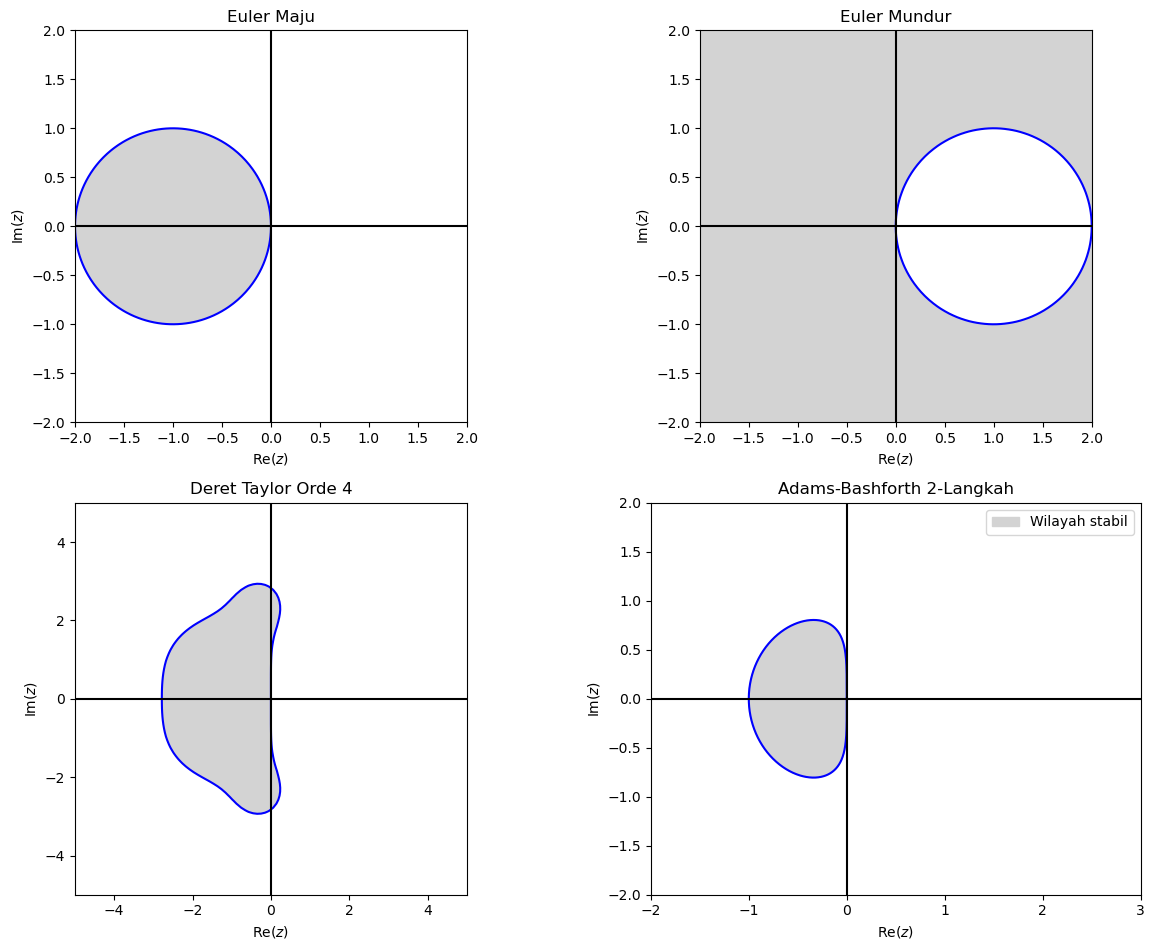

In [13]:
import numpy
import matplotlib.pyplot as plt

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2.0)
fig.set_figheight(fig.get_figheight() * 2.0)

# ==================================
# Euler Maju
axes = fig.add_subplot(2, 2, 1)
x = numpy.linspace(-2, 2, 100)
y = numpy.linspace(-2, 2, 100)
X, Y = numpy.meshgrid(x, y)
Z = X + 1j * Y

print("Euler Maju - Uji wilayah stabilitas")
z = -1 + 1j * 0
print(f"  Di dalam lingkaran: |1 + z| = {numpy.abs(1.0 + z):.4f}")
z = -3 + 1j * 0
print(f"  Di luar lingkaran:  |1 + z| = {numpy.abs(1.0 + z):.4f}")

axes.contourf(X, Y, numpy.abs(1.0 + Z), levels=[0, 1.0], colors=['lightgray'])  # isi wilayah stabil
axes.contour(X, Y, numpy.abs(1.0 + Z), levels=[1.0], colors='blue')             # garis batas
axes.plot(x, numpy.zeros(x.shape), 'k')
axes.plot(numpy.zeros(y.shape), y, 'k')
axes.set_aspect('equal')
axes.set_title("Euler Maju")
axes.set_xlabel(r"Re$(z)$")
axes.set_ylabel(r"Im$(z)$")

# ==================================
# Euler Mundur
axes = fig.add_subplot(2, 2, 2)
x = numpy.linspace(-2, 2, 100)
y = numpy.linspace(-2, 2, 100)
X, Y = numpy.meshgrid(x, y)
Z = X + 1j * Y

print("\nEuler Mundur - Uji wilayah stabilitas")
z = 2 + 1j * 0   # di dalam lingkaran (tidak stabil)
print(f"  Di dalam lingkaran: |1/(1-z)| = {numpy.abs(1.0 / (1.0 - z)):.4f}")
z = -1 + 1j * 0  # di luar lingkaran (stabil)
print(f"  Di luar lingkaran:  |1/(1-z)| = {numpy.abs(1.0 / (1.0 - z)):.4f}")

axes.contourf(X, Y, numpy.abs(1.0 / (1.0 - Z)), levels=[0, 1.0], colors=['lightgray'])
axes.contour(X, Y, numpy.abs(1.0 / (1.0 - Z)), levels=[1.0], colors='blue')
axes.plot(x, numpy.zeros(x.shape), 'k')
axes.plot(numpy.zeros(y.shape), y, 'k')
axes.set_aspect('equal')
axes.set_title("Euler Mundur")
axes.set_xlabel(r"Re$(z)$")
axes.set_ylabel(r"Im$(z)$")

# ==================================
# Deret Taylor Orde 4
axes = fig.add_subplot(2, 2, 3)
x = numpy.linspace(-5, 5, 100)
y = numpy.linspace(-5, 5, 100)
X, Y = numpy.meshgrid(x, y)
Z = X + 1j * Y

print("\nDeret Taylor Orde 4 - Uji wilayah stabilitas")
z = -1 + 1j * 0
print(f"  Di dalam wilayah: |R(z)| = {numpy.abs(1.0 + z + 0.5*z**2 + z**3/6 + z**4/24):.4f}")
z = -4 + 1j * 0
print(f"  Di luar wilayah:  |R(z)| = {numpy.abs(1.0 + z + 0.5*z**2 + z**3/6 + z**4/24):.4f}")

R_z = 1 + Z + 0.5 * Z**2 + (1.0/6.0) * Z**3 + (1.0/24.0) * Z**4  # R(z) orde 4
axes.contourf(X, Y, numpy.abs(R_z), levels=[0, 1.0], colors=['lightgray'])
axes.contour(X, Y, numpy.abs(R_z), levels=[1.0], colors='blue')
axes.plot(x, numpy.zeros(x.shape), 'k')
axes.plot(numpy.zeros(y.shape), y, 'k')
axes.set_aspect('equal')
axes.set_title("Deret Taylor Orde 4")
axes.set_xlabel(r"Re$(z)$")
axes.set_ylabel(r"Im$(z)$")

# ==================================
# Adams-Bashforth 2-Langkah
theta = numpy.linspace(0.0, 2.0 * numpy.pi, 1000)
xi = numpy.exp(1j * theta)

rho_2AB   = lambda xi: (xi - 1.0) * xi         # polinomial rho
sigma_2AB = lambda xi: (3.0 * xi - 1.0) / 2.0  # polinomial sigma
z_2AB     = rho_2AB(xi) / sigma_2AB(xi)         # batas wilayah stabilitas

axes = fig.add_subplot(2, 2, 4)
axes.fill(z_2AB.real, z_2AB.imag, color='lightgray', label='Wilayah stabil')
axes.plot(z_2AB.real, z_2AB.imag, 'b')
axes.plot([-2, 3], [0.0, 0.0], 'k')
axes.plot([0.0, 0.0], [-2, 2], 'k')
axes.set_aspect('equal')
axes.set_title("Adams-Bashforth 2-Langkah")
axes.set_xlabel(r"Re$(z)$")
axes.set_ylabel(r"Im$(z)$")
axes.set_xlim([-2, 3])
axes.set_ylim([-2, 2])
axes.legend(loc='upper right')

plt.tight_layout()
plt.show()